The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Testing Lambda Scale: 0.0...


Sample: 100%|██████████| 150/150 [00:02, 53.74it/s, step size=1.52e-01, acc. prob=0.985]
/Users/riyaaggarwal/miniforge3/envs/trees_nuts/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


Testing Lambda Scale: 10.0...


Sample: 100%|██████████| 150/150 [00:06, 22.64it/s, step size=1.19e-01, acc. prob=0.975]
/Users/riyaaggarwal/miniforge3/envs/trees_nuts/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


Testing Lambda Scale: 100.0...


...

Testing Lambda Scale: 500.0...


Sample: 100%|██████████| 150/150 [01:41,  1.47it/s, step size=1.35e-02, acc. prob=0.939]
/Users/riyaaggarwal/miniforge3/envs/trees_nuts/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(


Testing Lambda Scale: 1000.0...


Sample: 100%|██████████| 150/150 [01:53,  1.33it/s, step size=1.27e-02, acc. prob=0.888]
/Users/riyaaggarwal/miniforge3/envs/trees_nuts/lib/python3.11/site-packages/arviz/data/io_pyro.py:158: UserWarning: Could not get vectorized trace, log_likelihood group will be omitted. Check your model vectorization or set log_likelihood=False
  warnings.warn(



LAMBDA SCALE SEARCH MATRIX RESULTS
 lambda  divergences  tree_consistency_rate  median_branch_gap  unscaled_penalty  status
    0.0            0                 0.2013           0.692298          0.217832 success
   10.0            0                 0.2049           0.683223          0.268708 success
  100.0            0                 0.2418           0.584839          0.129970 success
  250.0            0                 0.2793           0.490251          0.070587 success
  500.0            0                 0.3324           0.434669          0.059840 success
 1000.0            0                 0.4310           0.409761          0.028618 success

[Diagnostic Plot Saved Successfully as 'violations_vs_gaussian_comparison.png']


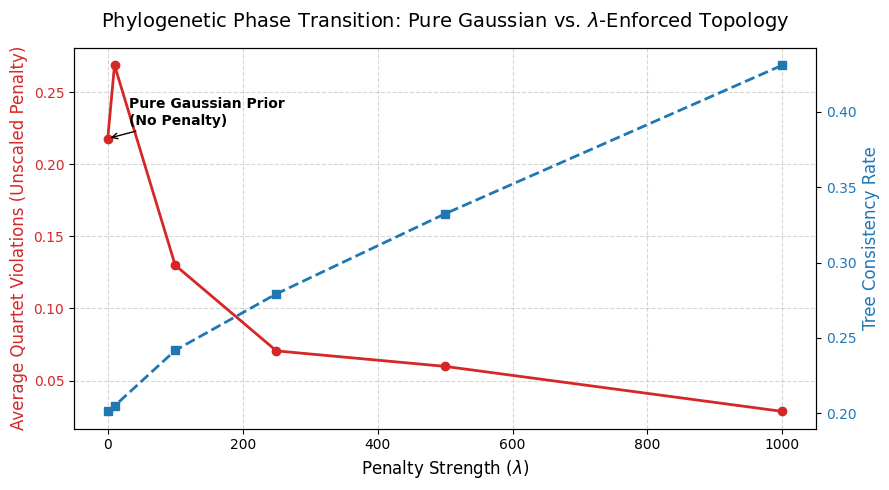

In [2]:
# Force Jupyter to reload your fixed penalty.py file
%load_ext autoreload
%autoreload 2

import sys
import os
# Ensure Python can find the src/ directory from your current path
sys.path.append(os.path.abspath(os.path.join("..")))
sys.path.append(os.path.abspath("."))

import torch
import pyro
import pyro.infer as infer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

# Importing custom modules
from src.model import PhylogeneticPrior
from src.diagnostics import get_fresh_test_quartets, evaluate_test_diagnostics
from src.geometry import compute_distance_matrix
from src.penalty import soft_four_point_penalty 

# --- Fixed Configuration ---
N = 50
K = 2
B_train = 100

# Controlled sweet spot settings enabled by your code fix
sigma_experimental = 0.4   
tau_experimental = 0.001   

# Generate validation set
test_quartets = get_fresh_test_quartets(N=N, B_test=100, seed=123)

# Search grid starting at 0.0 (Pure Gaussian Baseline) and increasing slowly
lambda_search_grid = [0.0, 10.0, 100.0, 250.0, 500.0, 1000.0]
compiled_results = []

for lmbda_val in lambda_search_grid:
    print(f"Testing Lambda Scale: {lmbda_val}...")
    
    pyro.clear_param_store()
    pyro.set_rng_seed(44)
    
    model = PhylogeneticPrior(N=N, K=K, B=B_train, seed=42)
    
    # Explicit attribute binding to bypass internal model.py routing bugs
    if hasattr(model, 'lmbda'): model.lmbda = lmbda_val
    if hasattr(model, 'sigma_u'): model.sigma_u = sigma_experimental
    if hasattr(model, 'tau'): model.tau = tau_experimental
    
    nuts_kernel = infer.NUTS(model.initialize, target_accept_prob=0.95)
    mcmc = infer.MCMC(nuts_kernel, num_samples=100, warmup_steps=50, num_chains=1)
    
    try:
        # Run the sampler with explicit parameters
        mcmc.run(lmbda=lmbda_val, sigma_u=sigma_experimental, tau=tau_experimental)
        
        posterior_samples = mcmc.get_samples()
        u_samples = posterior_samples["u"]
        
        # Project unconstrained samples to hyperbolic distance matrices
        with torch.no_grad():
            u_norm = torch.norm(u_samples, p=2, dim=-1, keepdim=True)
            x_samples = (u_samples / torch.clamp(u_norm, min=1e-7)) * torch.tanh(u_norm)
            D_samples = compute_distance_matrix(x_samples)
            
        metrics = evaluate_test_diagnostics(D_samples, test_quartets, epsilon=0.05, gamma=0.05)
        idata = az.from_pyro(mcmc)
        divergences = idata.sample_stats.diverging.sum().item()
        
        # Manual verification check to read the real unscaled quartet violations
        last_D_matrix = D_samples[-1]
        with torch.no_grad():
            raw_quartet_penalties = soft_four_point_penalty(
                last_D_matrix, 
                model.fixed_indices,
                tau=tau_experimental
            )
            unscaled_penalty_verified = raw_quartet_penalties.mean().item()
            
        compiled_results.append({
            "lambda": lmbda_val,
            "divergences": divergences,
            "tree_consistency_rate": metrics["tree_consistency_rate"],
            "median_branch_gap": metrics["quartet_gap"]["median"],
            "unscaled_penalty": unscaled_penalty_verified,
            "status": "success"
        })
        
    except (RuntimeError, ValueError) as e:
        print(f" -> Scale failed at lambda={lmbda_val}. Error type: {type(e).__name__}")
        compiled_results.append({
            "lambda": lmbda_val, "divergences": np.nan, "tree_consistency_rate": np.nan,
            "median_branch_gap": np.nan, "unscaled_penalty": np.nan, "status": "failed"
        })

# --- Compile Results Dataframe ---
df_sweep = pd.DataFrame(compiled_results)
print("\n" + "="*80)
print("LAMBDA SCALE SEARCH MATRIX RESULTS")
print("="*80)
print(df_sweep.to_string(index=False))
print("="*80)

# =========================================================================
# PLOTTING THE TRANSITION: GAUSSIAN VS TREE CONSTRAINT
# =========================================================================
# Create a dual-axis plot to map out the phase change clearly
fig, ax1 = plt.subplots(figsize=(9, 5))

# Plot 1: Unscaled Quartet Violations (Left Axis)
color = 'tab:red'
ax1.set_xlabel(r'Penalty Strength ($\lambda$)', fontsize=12)
ax1.set_ylabel('Average Quartet Violations (Unscaled Penalty)', color=color, fontsize=12)
line1 = ax1.plot(df_sweep['lambda'], df_sweep['unscaled_penalty'], color=color, marker='o', linewidth=2, label='Violations')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Tree Consistency Rate (Right Axis)
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Tree Consistency Rate', color=color, fontsize=12)
line2 = ax2.plot(df_sweep['lambda'], df_sweep['tree_consistency_rate'], color=color, marker='s', linestyle='--', linewidth=2, label='Consistency %')
ax2.tick_params(axis='y', labelcolor=color)

# Annotation for the pure Gaussian baseline
baseline_violations = df_sweep.loc[df_sweep['lambda'] == 0.0, 'unscaled_penalty'].values[0]
ax1.annotate('Pure Gaussian Prior\n(No Penalty)', 
             xy=(0.0, baseline_violations), 
             xytext=(15, 10), 
             textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color='black', lw=1),
             fontsize=10, fontweight='bold')

plt.title(r'Phylogenetic Phase Transition: Pure Gaussian vs. $\lambda$-Enforced Topology', fontsize=14, pad=15)
fig.tight_layout()

# Save the diagnostic image directly to your directory
plt.savefig('violations_vs_gaussian_comparison.png', dpi=300)
print("\n[Diagnostic Plot Saved Successfully as 'violations_vs_gaussian_comparison.png']")